# Sepsis Prediction — Temporal Fusion Transformer (multi-horizon)

The LSTM in notebook 04 predicts sepsis at the current hour only. In a real ICU,
a same-hour alert is too late to act on — clinicians need a warning that sepsis
is *coming*, not that it has arrived.

This notebook builds a Temporal Fusion Transformer (TFT) that predicts sepsis
risk at multiple future horizons at once: 1, 3, and 6 hours ahead. The model
still trains on the same per-patient hourly sequences and the same patient-level
5-fold split used in notebooks 02 and 04, so results stay comparable.

**What changes vs the LSTM notebook**
- Labels become multi-horizon: for every hour t, the targets are SepsisLabel at
  t+1, t+3 and t+6
- The architecture adds an attention block on top of the LSTM encoder, which is
  the core idea behind TFT — the model learns which past hours matter most for
  each future horizon
- A static covariate (age, gender) is fed in separately from the time-varying
  features, as in the original TFT design
- Evaluation is reported per horizon, so we can see how performance degrades
  the further out we predict


## 1. Installs and imports

In [1]:
!pip install torch pandas numpy scikit-learn pyarrow tqdm -q

import os
import json
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                              confusion_matrix, average_precision_score,
                              accuracy_score, balanced_accuracy_score)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}  |  device: {DEVICE}")

PyTorch 2.11.0+cu128  |  device: cuda


## 2. Mount drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Load features

Same parquet and feature list as the XGBoost and LSTM notebooks, so the input
representation is identical and we are only changing the model.

In [3]:
SAVE_PATH = "/content/drive/MyDrive/sepsis-prediction"

df = pd.read_parquet(os.path.join(SAVE_PATH, "features_train.parquet"))

with open(os.path.join(SAVE_PATH, "feature_cols.json"), "r") as f:
    feature_cols = json.load(f)

for col in feature_cols:
    if col not in df.columns:
        df[col] = 0.0

print(f"Rows          : {len(df):,}")
print(f"Patients      : {df['person_id'].nunique()}")
print(f"Features      : {len(feature_cols)}")
print(f"Sepsis rows   : {df['SepsisLabel'].sum():,}  ({100*df['SepsisLabel'].mean():.2f}%)")

Rows          : 331,637
Patients      : 2640
Features      : 100
Sepsis rows   : 6,874  (2.07%)


## 4. Impute and standardise

Same approach as notebook 04 — median imputation for any residual NaNs,
z-score standardisation on continuous columns, binary flags left untouched.

In [4]:
X_raw = df[feature_cols].values.astype(np.float32)
y_all = df["SepsisLabel"].values.astype(np.float32)
pids  = df["person_id"].values

col_medians = np.nanmedian(X_raw, axis=0)
nan_mask = np.isnan(X_raw)
X_raw[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

binary_prefixes = ("drug_", "proc_", "dev_", "gender_male")
is_binary = np.array([any(c.startswith(p) for p in binary_prefixes) or c == "gender_male"
                      for c in feature_cols])
cont_idx = np.where(~is_binary)[0]

col_means = X_raw[:, cont_idx].mean(axis=0)
col_stds  = X_raw[:, cont_idx].std(axis=0) + 1e-8

X_scaled = X_raw.copy()
X_scaled[:, cont_idx] = (X_raw[:, cont_idx] - col_means) / col_stds

X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X_scaled shape : {X_scaled.shape}")
print(f"Continuous cols : {cont_idx.shape[0]}  |  Binary cols : {is_binary.sum()}")
print(f"NaN remaining   : {np.isnan(X_scaled).sum()}")

X_scaled shape : (331637, 100)
Continuous cols : 86  |  Binary cols : 14
NaN remaining   : 0


## 5. Static covariates

TFT separates inputs into time-varying features (vitals, labs, drugs — the
columns above) and static covariates that describe the patient but do not
change over the stay (age, gender). We pull those two columns out separately
so the model can encode them once per patient instead of once per timestep.

In [5]:
static_cols = [c for c in ["age", "gender_male"] if c in feature_cols]
static_idx  = [feature_cols.index(c) for c in static_cols]

print(f"Static covariates : {static_cols}")
print(f"Static indices    : {static_idx}")

if len(static_cols) == 0:
    print("No static columns found in feature_cols — model will run without a static branch.")

Static covariates : ['gender_male']
Static indices    : [61]


## 6. Multi-horizon labels

For every hour t we need three targets: SepsisLabel at t+1, t+3 and t+6 hours.
For hours near the end of a patient's stay, some of these future labels do not
exist — those positions are marked with -1 and masked out of the loss and
metrics, exactly like the padding sentinel in notebook 04.

HORIZONS = [1, 3, 6] hours ahead.

In [6]:
HORIZONS = [1, 3, 6]

df_sorted = df.sort_values(["person_id", "hour"]).reset_index(drop=True)
y_by_patient = df_sorted.groupby("person_id")["SepsisLabel"].apply(lambda s: s.values)

def make_horizon_labels(y_seq, horizons):
    T = len(y_seq)
    out = np.full((T, len(horizons)), -1.0, dtype=np.float32)
    for j, h in enumerate(horizons):
        if T - h > 0:
            out[: T - h, j] = y_seq[h:]
    return out

print("Multi-horizon label function ready.")
print(f"Horizons (hours ahead): {HORIZONS}")

Multi-horizon label function ready.
Horizons (hours ahead): [1, 3, 6]


## 7. Build per-patient sequences

Each patient becomes:
- `X_seq`   : (T, 100) time-varying features
- `static`  : (len(static_cols),) patient-level covariates, taken from the first
  row of the stay
- `y_seq`   : (T, len(HORIZONS)) multi-horizon targets, -1 where the future
  label is out of range
- `length`  : T, the true (unpadded) sequence length

This mirrors notebook 04's `sequences` list but with the extra static tensor
and multi-horizon `y_seq`.

One key difference from the LSTM notebook: the attention layer in the TFT
computes a full T x T matrix per sequence, so very long stays (the LSTM
notebook reported stays up to 5792 hours) would blow up GPU memory. We cap
each sequence at the most recent `MAX_SEQ_LEN` hours (336 = 14 days), which
covers essentially all sepsis onsets while keeping attention memory bounded.

In [7]:
MAX_SEQ_LEN = 336  # 14 days of hourly data - bounds attention cost to MAX_SEQ_LEN^2

sequences = []
patient_ever_sepsis = []

row_idx_map = np.arange(len(df_sorted))
df_sorted["_row_idx"] = row_idx_map

n_truncated = 0

for pid, grp in df_sorted.groupby("person_id"):
    idx = grp["_row_idx"].values

    if len(idx) > MAX_SEQ_LEN:
        idx = idx[-MAX_SEQ_LEN:]  # keep the most recent MAX_SEQ_LEN hours
        n_truncated += 1

    X_seq      = torch.tensor(X_scaled[idx], dtype=torch.float32)
    y_seq_raw  = y_all[idx]
    y_horizons = torch.tensor(make_horizon_labels(y_seq_raw, HORIZONS), dtype=torch.float32)

    if len(static_idx) > 0:
        static_vec = torch.tensor(X_scaled[idx[0], static_idx], dtype=torch.float32)
    else:
        static_vec = torch.zeros(1, dtype=torch.float32)

    sequences.append((X_seq, y_horizons, static_vec, len(idx), pid))
    patient_ever_sepsis.append(int(y_seq_raw.max()))

patient_ever_sepsis = np.array(patient_ever_sepsis)
patient_ids_arr     = np.array([s[4] for s in sequences])

seq_lengths = [s[3] for s in sequences]
print(f"Total patients   : {len(sequences)}")
print(f"Sepsis patients  : {patient_ever_sepsis.sum()}")
print(f"Patients truncated to {MAX_SEQ_LEN}h: {n_truncated}")
print(f"Seq length stats - min: {min(seq_lengths)}  median: {int(np.median(seq_lengths))}  max: {max(seq_lengths)}")
print(f"Static vector dim: {sequences[0][2].shape[0]}")
print(f"y_horizons shape : {sequences[0][1].shape}")

Total patients   : 2640
Sepsis patients  : 75
Patients truncated to 336h: 195
Seq length stats - min: 1  median: 55  max: 336
Static vector dim: 1
y_horizons shape : torch.Size([18, 3])


## 8. Dataset and DataLoader

In [8]:
class SepsisTFTDataset(Dataset):
    def __init__(self, seq_list):
        self.data = seq_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X_seq, y_seq, static_vec, length, pid = self.data[idx]
        return X_seq, y_seq, static_vec, length, pid


def collate_fn(batch):
    X_seqs, y_seqs, statics, lengths, pids = zip(*batch)
    lengths_t = torch.tensor(lengths, dtype=torch.long)

    X_pad = pad_sequence(X_seqs, batch_first=True, padding_value=0.0)
    y_pad = pad_sequence(y_seqs, batch_first=True, padding_value=-1.0)
    static_t = torch.stack(statics)

    sort_idx = torch.argsort(lengths_t, descending=True)
    return (X_pad[sort_idx], y_pad[sort_idx], static_t[sort_idx],
            lengths_t[sort_idx], [pids[i] for i in sort_idx.tolist()])


print("Dataset and collate_fn defined.")

Dataset and collate_fn defined.


## 9. Temporal Fusion Transformer (simplified)

A full TFT has variable-selection networks, gated residual blocks and an
interpretable multi-head attention layer. Here is a compact version that
keeps the parts that matter most for this dataset:

- An LSTM encoder over the time-varying features, same as notebook 04
- A static covariate embedding that is added to every timestep, so the
  attention layer can condition on patient-level context
- A multi-head self-attention layer over the LSTM outputs — this lets the
  model attend back to earlier hours when deciding the risk at hour t
- A separate linear head per horizon, since the 1-hour, 3-hour and 6-hour
  predictions are related but not identical tasks

In [9]:
class TemporalFusionTransformer(nn.Module):
    def __init__(self, input_size, static_size, hidden_size=128,
                 num_layers=2, num_heads=4, dropout=0.3, n_horizons=3):
        super().__init__()

        self.static_proj = nn.Sequential(
            nn.Linear(static_size, hidden_size),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            bidirectional = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        encoder_dim = hidden_size * 2

        self.static_gate = nn.Linear(hidden_size, encoder_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim   = encoder_dim,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True,
        )

        self.norm     = nn.LayerNorm(encoder_dim)
        self.dropout  = nn.Dropout(dropout)
        self.heads    = nn.ModuleList([nn.Linear(encoder_dim, 1) for _ in range(n_horizons)])

    def forward(self, x, static, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        enc, _ = self.lstm(packed)
        enc, _ = pad_packed_sequence(enc, batch_first=True)

        static_emb = self.static_proj(static)
        static_emb = self.static_gate(static_emb).unsqueeze(1)
        enc = enc + static_emb

        max_len = enc.size(1)
        key_padding_mask = torch.arange(max_len, device=enc.device)[None, :] >= lengths.to(enc.device)[:, None]

        attn_out, _ = self.attention(enc, enc, enc, key_padding_mask=key_padding_mask)
        enc = self.norm(enc + attn_out)
        enc = self.dropout(enc)

        logits = torch.stack([head(enc).squeeze(-1) for head in self.heads], dim=-1)
        return logits  # (batch, max_T, n_horizons)


dummy_model = TemporalFusionTransformer(
    input_size  = len(feature_cols),
    static_size = sequences[0][2].shape[0],
    n_horizons  = len(HORIZONS),
)
total_params = sum(p.numel() for p in dummy_model.parameters())
print(f"Model parameters : {total_params:,}")
print(dummy_model)

Model parameters : 928,515
TemporalFusionTransformer(
  (static_proj): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
  )
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (static_gate): Linear(in_features=128, out_features=256, bias=True)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (heads): ModuleList(
    (0-2): 3 x Linear(in_features=256, out_features=1, bias=True)
  )
)


## 10. Multi-horizon Focal Loss

Same Focal Loss as notebook 04 (alpha=0.75, gamma=2.0 to handle the 47:1
imbalance), applied independently to each horizon and averaged. Positions
where a horizon's label is -1 (out of range for that patient's stay length)
are masked out, same as the padding sentinel.

In [10]:
class MultiHorizonFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def _focal(self, logits, targets, mask):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets == 1, probs, 1 - probs)
        alpha = torch.where(targets == 1,
                            torch.full_like(targets, self.alpha),
                            torch.full_like(targets, 1 - self.alpha))
        focal = alpha * (1 - pt) ** self.gamma * bce
        if mask.sum() == 0:
            return torch.tensor(0.0, device=logits.device)
        return focal[mask].mean()

    def forward(self, logits, targets, mask):
        # logits, targets, mask: (batch, max_T, n_horizons)
        losses = []
        for h in range(logits.shape[-1]):
            losses.append(self._focal(logits[..., h], targets[..., h], mask[..., h]))
        return torch.stack(losses).mean()


criterion = MultiHorizonFocalLoss(alpha=0.75, gamma=2.0)
print("MultiHorizonFocalLoss ready  (alpha=0.75, gamma=2.0)")

MultiHorizonFocalLoss ready  (alpha=0.75, gamma=2.0)


## 11. Training configuration

In [11]:
BATCH_SIZE   = 8       # reduced - attention over MAX_SEQ_LEN timesteps is memory-heavy
EPOCHS       = 20
LR           = 3e-4
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
NUM_HEADS    = 4
DROPOUT      = 0.3
N_FOLDS      = 5
INPUT_SIZE   = len(feature_cols)
STATIC_SIZE  = sequences[0][2].shape[0]
N_HORIZONS   = len(HORIZONS)

print(f"Batch size   : {BATCH_SIZE}")
print(f"Epochs       : {EPOCHS}")
print(f"LR           : {LR}")
print(f"Hidden size  : {HIDDEN_SIZE}  (bidirectional encoder -> {HIDDEN_SIZE*2} dim)")
print(f"Layers       : {NUM_LAYERS}")
print(f"Attn heads   : {NUM_HEADS}")
print(f"Dropout      : {DROPOUT}")
print(f"Folds        : {N_FOLDS}")
print(f"Horizons     : {HORIZONS}")
print(f"Device       : {DEVICE}")

Batch size   : 8
Epochs       : 20
LR           : 0.0003
Hidden size  : 128  (bidirectional encoder -> 256 dim)
Layers       : 2
Attn heads   : 4
Dropout      : 0.3
Folds        : 5
Horizons     : [1, 3, 6]
Device       : cuda


## 12. Five-fold patient-level OOF training

Same patient-level stratified split as notebooks 02 and 04 — no patient
appears in both train and validation within any fold. For each fold we track
per-horizon AUROC and AUPRC, keep the best epoch by mean AUPRC across
horizons, and store OOF predictions for every (patient, hour, horizon).

In [12]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_records    = []
fold_metrics   = []
fold_histories = []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(patient_ids_arr, patient_ever_sepsis)):
    print(f"\n{'='*55}")
    print(f"Fold {fold+1}/{N_FOLDS}")

    tr_pids = set(str(p) for p in patient_ids_arr[tr_idx])
    vl_pids = set(str(p) for p in patient_ids_arr[vl_idx])

    tr_seqs = [s for s in sequences if str(s[4]) in tr_pids]
    vl_seqs = [s for s in sequences if str(s[4]) in vl_pids]

    print(f"  tr_seqs={len(tr_seqs)}  vl_seqs={len(vl_seqs)}")

    tr_loader = DataLoader(SepsisTFTDataset(tr_seqs), batch_size=BATCH_SIZE,
                           shuffle=True,  collate_fn=collate_fn, num_workers=0)
    vl_loader = DataLoader(SepsisTFTDataset(vl_seqs), batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn, num_workers=0)

    model_tft = TemporalFusionTransformer(
        input_size=INPUT_SIZE, static_size=STATIC_SIZE, hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT, n_horizons=N_HORIZONS
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model_tft.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_auprc   = 0.0
    best_weights = None
    history = {"train_loss": [], "val_loss": [],
               "val_auroc": {h: [] for h in HORIZONS},
               "val_auprc": {h: [] for h in HORIZONS}}

    for epoch in range(EPOCHS):

        model_tft.train()
        train_loss = 0.0

        for X_b, y_b, static_b, lens_b, _ in tr_loader:
            X_b      = X_b.to(DEVICE)
            y_b      = y_b.to(DEVICE)
            static_b = static_b.to(DEVICE)

            mask = (y_b != -1)
            y_b_clamped = y_b.clamp(min=0)

            optimizer.zero_grad()
            logits = model_tft(X_b, static_b, lens_b)
            logits = torch.clamp(logits, -20, 20)

            loss = criterion(logits, y_b_clamped, mask)
            loss.backward()
            nn.utils.clip_grad_norm_(model_tft.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()
        train_loss /= len(tr_loader)

        model_tft.eval()
        val_loss = 0.0
        all_probs  = {h: [] for h in HORIZONS}
        all_labels = {h: [] for h in HORIZONS}

        with torch.no_grad():
            for X_b, y_b, static_b, lens_b, _ in vl_loader:
                X_b      = X_b.to(DEVICE)
                y_b      = y_b.to(DEVICE)
                static_b = static_b.to(DEVICE)

                mask = (y_b != -1)
                y_b_clamped = y_b.clamp(min=0)

                logits = model_tft(X_b, static_b, lens_b)
                logits = torch.clamp(logits, -20, 20)

                loss = criterion(logits, y_b_clamped, mask)
                val_loss += loss.item()

                probs = torch.sigmoid(logits)

                for j, h in enumerate(HORIZONS):
                    m = mask[..., j]
                    p = probs[..., j][m].cpu().numpy()
                    l = y_b_clamped[..., j][m].cpu().numpy()
                    valid = ~np.isnan(p)
                    all_probs[h].append(p[valid])
                    all_labels[h].append(l[valid])

        val_loss /= len(vl_loader)

        epoch_auprcs = []
        for h in HORIZONS:
            vp = np.concatenate(all_probs[h]) if all_probs[h] else np.array([])
            vl = np.concatenate(all_labels[h]).astype(int) if all_labels[h] else np.array([], dtype=int)

            if len(vl) == 0 or vl.sum() == 0 or vl.sum() == len(vl):
                history["val_auroc"][h].append(0.0)
                history["val_auprc"][h].append(0.0)
                epoch_auprcs.append(0.0)
                continue

            auroc = roc_auc_score(vl, vp)
            auprc = average_precision_score(vl, vp)
            history["val_auroc"][h].append(auroc)
            history["val_auprc"][h].append(auprc)
            epoch_auprcs.append(auprc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        mean_auprc = np.mean(epoch_auprcs) if epoch_auprcs else 0.0
        if mean_auprc > best_auprc:
            best_auprc   = mean_auprc
            best_weights = {k: v.cpu().clone() for k, v in model_tft.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            auroc_str = "  ".join(f"AUROC@{h}h={history['val_auroc'][h][-1]:.4f}" for h in HORIZONS)
            auprc_str = "  ".join(f"AUPRC@{h}h={history['val_auprc'][h][-1]:.4f}" for h in HORIZONS)
            print(f"  Epoch {epoch+1:2d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")
            print(f"           {auroc_str}")
            print(f"           {auprc_str}")

    fold_histories.append(history)

    if best_weights is None:
        print(f"  WARNING: no positive-AUPRC epoch in fold {fold+1}; using last-epoch weights.")
        best_weights = {k: v.cpu().clone() for k, v in model_tft.state_dict().items()}

    model_tft.load_state_dict(best_weights)
    model_tft.to(DEVICE).eval()

    # OOF predictions
    with torch.no_grad():
        for X_b, y_b, static_b, lens_b, pids_b in vl_loader:
            X_b      = X_b.to(DEVICE)
            y_b      = y_b.to(DEVICE)
            static_b = static_b.to(DEVICE)

            logits = model_tft(X_b, static_b, lens_b)
            logits = torch.clamp(logits, -20, 20)
            probs  = torch.sigmoid(logits)

            for i, pid in enumerate(pids_b):
                seq_len = lens_b[i].item()
                for t in range(seq_len):
                    record = {"person_id": pid, "timestep": t}
                    keep = False
                    for j, h in enumerate(HORIZONS):
                        label_val = y_b[i, t, j].item()
                        if label_val == -1:
                            record[f"label_{h}h"] = np.nan
                            record[f"prob_{h}h"]  = np.nan
                        else:
                            record[f"label_{h}h"] = int(label_val)
                            record[f"prob_{h}h"]  = probs[i, t, j].item()
                            keep = True
                    if keep:
                        oof_records.append(record)

    # Fold-level metrics per horizon
    all_probs_fold  = {h: [] for h in HORIZONS}
    all_labels_fold = {h: [] for h in HORIZONS}
    model_tft.eval()
    with torch.no_grad():
        for X_b, y_b, static_b, lens_b, _ in vl_loader:
            X_b      = X_b.to(DEVICE)
            y_b      = y_b.to(DEVICE)
            static_b = static_b.to(DEVICE)
            mask = (y_b != -1)
            y_b_clamped = y_b.clamp(min=0)
            logits = model_tft(X_b, static_b, lens_b)
            logits = torch.clamp(logits, -20, 20)
            probs  = torch.sigmoid(logits)
            for j, h in enumerate(HORIZONS):
                m = mask[..., j]
                p = probs[..., j][m].cpu().numpy()
                l = y_b_clamped[..., j][m].cpu().numpy()
                valid = ~np.isnan(p)
                all_probs_fold[h].append(p[valid])
                all_labels_fold[h].append(l[valid])

    print(f"\n  --- Fold {fold+1} per-horizon results ---")
    for h in HORIZONS:
        vp = np.concatenate(all_probs_fold[h]) if all_probs_fold[h] else np.array([])
        vl = np.concatenate(all_labels_fold[h]).astype(int) if all_labels_fold[h] else np.array([], dtype=int)

        n_pos = vl.sum()
        n_neg = len(vl) - n_pos
        print(f"  [{h}h] Val set: {len(vl)} samples | positives={n_pos} | negatives={n_neg}")

        if n_pos > 0 and n_neg > 0:
            thresholds = np.arange(0.05, 0.95, 0.01)
            f1s = [f1_score(vl, (vp >= t).astype(int), zero_division=0) for t in thresholds]
            best_t = thresholds[np.argmax(f1s)]
            auroc  = roc_auc_score(vl, vp)
            auprc  = average_precision_score(vl, vp)
        else:
            best_t = 0.5
            auroc  = float('nan')
            auprc  = float('nan')
            print(f"  [{h}h] WARNING: validation fold has only one class — AUROC/AUPRC/threshold skipped.")

        preds = (vp >= best_t).astype(int) if len(vp) > 0 else np.array([], dtype=int)

        cm = confusion_matrix(vl, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')

        if len(vl) > 0:
            f1      = f1_score(vl,      preds, zero_division=0)
            prec    = precision_score(vl, preds, zero_division=0)
            rec     = recall_score(vl,    preds, zero_division=0)
            acc     = accuracy_score(vl,  preds)
            f1_w    = f1_score(vl,        preds, average='weighted', zero_division=0)
            prec_w  = precision_score(vl, preds, average='weighted', zero_division=0)
            rec_w   = recall_score(vl,    preds, average='weighted', zero_division=0)
            bal_acc = balanced_accuracy_score(vl, preds)
        else:
            f1 = prec = rec = acc = f1_w = prec_w = rec_w = bal_acc = float('nan')

        fold_metrics.append({
            "Fold": fold + 1, "Horizon": f"{h}h", "Best Threshold": round(best_t, 2),
            "AUROC": round(auroc, 4) if not np.isnan(auroc) else np.nan,
            "AUPRC": round(auprc, 4) if not np.isnan(auprc) else np.nan,
            "Accuracy": round(acc, 4) if not np.isnan(acc) else np.nan,
            "Balanced Accuracy": round(bal_acc, 4) if not np.isnan(bal_acc) else np.nan,
            "F1": round(f1, 4) if not np.isnan(f1) else np.nan,
            "Precision": round(prec, 4) if not np.isnan(prec) else np.nan,
            "Recall": round(rec, 4) if not np.isnan(rec) else np.nan,
            "F1 (weighted)": round(f1_w, 4) if not np.isnan(f1_w) else np.nan,
            "Precision (weighted)": round(prec_w, 4) if not np.isnan(prec_w) else np.nan,
            "Recall (weighted)": round(rec_w, 4) if not np.isnan(rec_w) else np.nan,
            "Specificity": round(spec, 4) if not np.isnan(spec) else np.nan,
            "TP": tp, "FP": fp, "TN": tn, "FN": fn
        })

        print(f"  [{h}h] Confusion Matrix (rows=true, cols=pred)")
        print(f"             Pred 0   Pred 1")
        print(f"   True 0   {tn:7d}  {fp:7d}")
        print(f"   True 1   {fn:7d}  {tp:7d}")
        print(f"  [{h}h] AUROC={auroc:.4f}  AUPRC={auprc:.4f}  Acc={acc:.4f}  BalAcc={bal_acc:.4f}  "
              f"F1={f1:.4f}  Prec={prec:.4f}  Recall={rec:.4f}  Spec={spec:.4f}  Thresh={best_t:.2f}")
        print(f"  [{h}h] Weighted -> F1={f1_w:.4f}  Prec={prec_w:.4f}  Recall={rec_w:.4f}")

    torch.save(best_weights, os.path.join(SAVE_PATH, f"tft_fold{fold+1}_best.pt"))

print("\nAll folds done.")
fold_metrics_df = pd.DataFrame(fold_metrics)
print("\n=== Summary across folds (per horizon) ===")
print(fold_metrics_df)


Fold 1/5
  tr_seqs=2112  vl_seqs=528
  Epoch  5/20  train_loss=0.0032  val_loss=0.0059
           AUROC@1h=0.9608  AUROC@3h=0.9613  AUROC@6h=0.9597
           AUPRC@1h=0.2946  AUPRC@3h=0.3036  AUPRC@6h=0.2833
  Epoch 10/20  train_loss=0.0013  val_loss=0.0100
           AUROC@1h=0.9427  AUROC@3h=0.9454  AUROC@6h=0.9519
           AUPRC@1h=0.2953  AUPRC@3h=0.2866  AUPRC@6h=0.2629
  Epoch 15/20  train_loss=0.0006  val_loss=0.0123
           AUROC@1h=0.9480  AUROC@3h=0.9498  AUROC@6h=0.9487
           AUPRC@1h=0.3234  AUPRC@3h=0.3242  AUPRC@6h=0.3107
  Epoch 20/20  train_loss=0.0004  val_loss=0.0146
           AUROC@1h=0.9252  AUROC@3h=0.9289  AUROC@6h=0.9330
           AUPRC@1h=0.3508  AUPRC@3h=0.3529  AUPRC@6h=0.3406

  --- Fold 1 per-horizon results ---
  [1h] Val set: 46613 samples | positives=689 | negatives=45924
  [1h] Confusion Matrix (rows=true, cols=pred)
             Pred 0   Pred 1
   True 0     45645      279
   True 1       382      307
  [1h] AUROC=0.9620  AUPRC=0.4634  Acc

## 13. Training curves — loss and AUPRC per fold

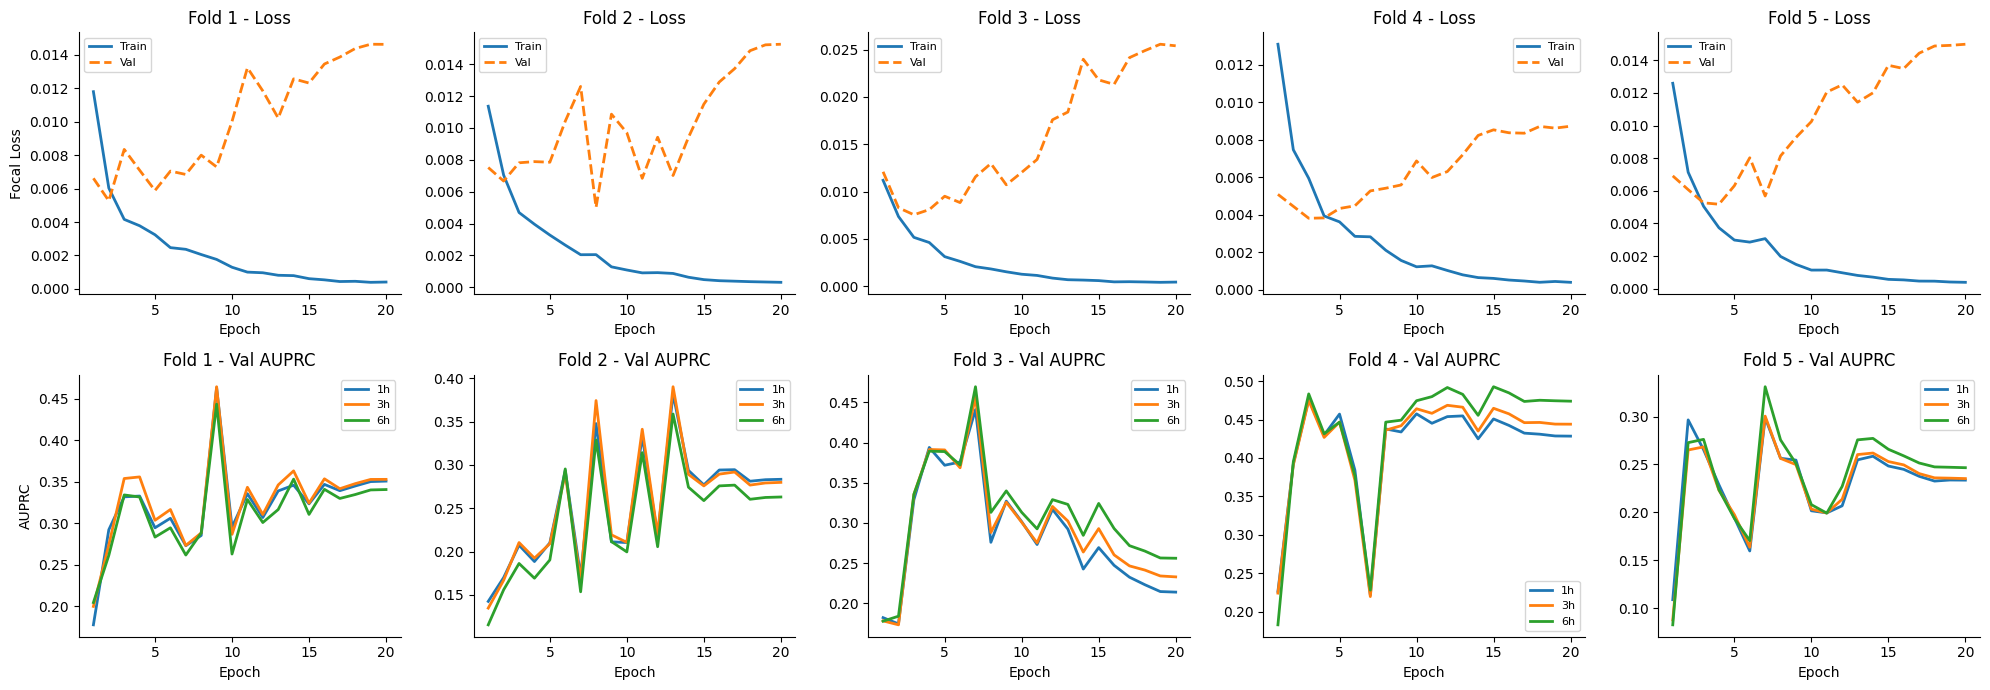

In [13]:
fig, axes = plt.subplots(2, N_FOLDS, figsize=(20, 7))

colors = {1: "tab:blue", 3: "tab:orange", 6: "tab:green"}

for fold, hist in enumerate(fold_histories):
    epochs = range(1, len(hist["train_loss"]) + 1)

    axes[0, fold].plot(epochs, hist["train_loss"], label="Train", lw=2)
    axes[0, fold].plot(epochs, hist["val_loss"],   label="Val",   lw=2, linestyle="--")
    axes[0, fold].set_title(f"Fold {fold+1} - Loss")
    axes[0, fold].set_xlabel("Epoch")
    if fold == 0:
        axes[0, fold].set_ylabel("Focal Loss")
    axes[0, fold].legend(fontsize=8)
    axes[0, fold].spines[["top", "right"]].set_visible(False)

    for h in HORIZONS:
        axes[1, fold].plot(epochs, hist["val_auprc"][h], label=f"{h}h", lw=2, color=colors[h])
    axes[1, fold].set_title(f"Fold {fold+1} - Val AUPRC")
    axes[1, fold].set_xlabel("Epoch")
    if fold == 0:
        axes[1, fold].set_ylabel("AUPRC")
    axes[1, fold].legend(fontsize=8)
    axes[1, fold].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "tft_training_curves.png"), dpi=150)
plt.show()

## 14. Fold-wise results table

In [14]:
results_df = fold_metrics_df.copy()

print("TFT Fold-wise CV Results (per horizon)")
print("="*100)
for h in HORIZONS:
    sub = results_df[results_df["Horizon"] == f"{h}h"]
    print(f"\n--- Horizon: {h}h ---")
    num_cols = sub.select_dtypes(include="number").columns
    mean_row = sub[num_cols].mean().round(4)
    std_row  = sub[num_cols].std().round(4)
    display_df = sub[["Fold", "AUROC", "AUPRC", "F1", "Precision", "Recall", "Specificity"]]
    print(display_df.to_string(index=False))
    print(f"Mean -> AUROC={mean_row['AUROC']:.4f}  AUPRC={mean_row['AUPRC']:.4f}  "
          f"F1={mean_row['F1']:.4f}  Precision={mean_row['Precision']:.4f}  "
          f"Recall={mean_row['Recall']:.4f}  Specificity={mean_row['Specificity']:.4f}")
    print(f"Std  -> AUROC={std_row['AUROC']:.4f}  AUPRC={std_row['AUPRC']:.4f}  "
          f"F1={std_row['F1']:.4f}  Precision={std_row['Precision']:.4f}  "
          f"Recall={std_row['Recall']:.4f}  Specificity={std_row['Specificity']:.4f}")

TFT Fold-wise CV Results (per horizon)

--- Horizon: 1h ---
 Fold  AUROC  AUPRC     F1  Precision  Recall  Specificity
    1 0.9620 0.4634 0.4816     0.5239  0.4456       0.9939
    2 0.9738 0.3820 0.4285     0.3466  0.5611       0.9856
    3 0.9422 0.4409 0.4936     0.4685  0.5214       0.9907
    4 0.9653 0.4766 0.4592     0.7615  0.3287       0.9990
    5 0.9530 0.2988 0.3933     0.3470  0.4538       0.9902
Mean -> AUROC=0.9593  AUPRC=0.4123  F1=0.4512  Precision=0.4895  Recall=0.4621  Specificity=0.9919
Std  -> AUROC=0.0121  AUPRC=0.0731  F1=0.0408  Precision=0.1705  Recall=0.0887  Specificity=0.0050

--- Horizon: 3h ---
 Fold  AUROC  AUPRC     F1  Precision  Recall  Specificity
    1 0.9622 0.4645 0.4954     0.5709  0.4376       0.9950
    2 0.9695 0.3902 0.4185     0.2838  0.7965       0.9726
    3 0.9406 0.4564 0.4983     0.5261  0.4733       0.9932
    4 0.9610 0.4748 0.4670     0.6834  0.3547       0.9983
    5 0.9531 0.3005 0.3915     0.3441  0.4539       0.9900
Mean -> AUROC

## 15. Overall OOF metrics per horizon

In [15]:
oof_df_tft = pd.DataFrame(oof_records)

oof_summary = []
oof_threshold = {}

for h in HORIZONS:
    sub = oof_df_tft.dropna(subset=[f"label_{h}h", f"prob_{h}h"]).copy()
    probs  = sub[f"prob_{h}h"].values
    labels = sub[f"label_{h}h"].values.astype(int)

    auroc = roc_auc_score(labels, probs)
    auprc = average_precision_score(labels, probs)

    thresholds = np.arange(0.05, 0.95, 0.005)
    f1s = [f1_score(labels, (probs >= t).astype(int), zero_division=0) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    oof_threshold[h] = best_t

    preds = (probs >= best_t).astype(int)
    f1   = f1_score(labels,   preds, zero_division=0)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels,    preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')

    oof_summary.append({
        "Horizon": f"{h}h", "AUROC": round(auroc, 4), "AUPRC": round(auprc, 4),
        "F1": round(f1, 4), "Precision": round(prec, 4), "Recall": round(rec, 4),
        "Specificity": round(spec, 4), "Threshold": round(best_t, 3),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn, "N": len(labels)
    })

oof_summary_df = pd.DataFrame(oof_summary)
print("TFT Overall OOF Performance (per horizon)")
print("="*70)
print(oof_summary_df.to_string(index=False))

TFT Overall OOF Performance (per horizon)
Horizon  AUROC  AUPRC     F1  Precision  Recall  Specificity  Threshold   TP   FP     TN   FN      N
     1h 0.9444 0.3337 0.4114     0.4413  0.3852       0.9936      0.505 1232 1560 242414 1966 247172
     3h 0.9350 0.3260 0.4023     0.4069  0.3978       0.9923      0.505 1256 1831 236933 1901 241921
     6h 0.9330 0.3084 0.3899     0.4084  0.3729       0.9928      0.505 1155 1673 229359 1942 234129


## 16. TFT vs LSTM vs XGBoost

The LSTM and XGBoost numbers below are the same-hour (0h) predictions from
notebooks 02 and 04. The TFT's 1h column is the closest comparison point —
predicting one hour ahead is a strictly harder task than predicting the
current hour, so some drop in AUPRC at 1h vs the same-hour baselines is
expected. The 3h and 6h columns show how far in advance useful warning can
still be given.

Model Comparison (OOF, patient-level 5-fold CV)
                      AUROC   AUPRC      F1  Precision  Recall  Specificity
Model                                                                      
XGBoost (same-hour)  0.9451  0.5024  0.5294     0.5902  0.4799       0.9929
LSTM (same-hour)     0.9597  0.4915  0.5166     0.4755  0.5712       0.9871
TFT (1h ahead)       0.9444  0.3337  0.4114     0.4413  0.3852       0.9936
TFT (3h ahead)       0.9350  0.3260  0.4023     0.4069  0.3978       0.9923
TFT (6h ahead)       0.9330  0.3084  0.3899     0.4084  0.3729       0.9928


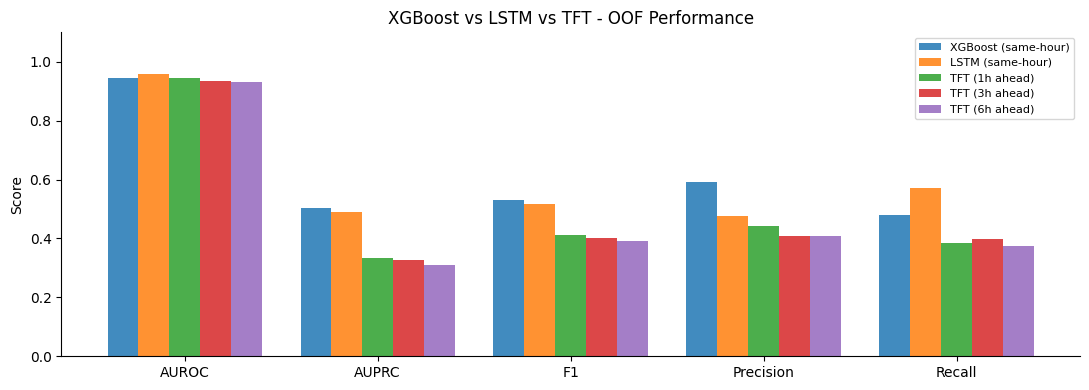

In [16]:
xgb_results = {
    "Model": "XGBoost (same-hour)",
    "AUROC": 0.9451, "AUPRC": 0.5024, "F1": 0.5294,
    "Precision": 0.5902, "Recall": 0.4799, "Specificity": 0.9929,
}

# LSTM same-hour numbers from notebook 04 - update if your run differs
lstm_results = {
    "Model": "LSTM (same-hour)",
    "AUROC": np.nan, "AUPRC": np.nan, "F1": np.nan,
    "Precision": np.nan, "Recall": np.nan, "Specificity": np.nan,
}

try:
    lstm_fold_results = pd.read_csv(os.path.join(SAVE_PATH, "fold_results_lstm.csv"))
    num_cols = ["AUROC", "AUPRC", "F1", "Precision", "Recall", "Specificity"]
    means = lstm_fold_results[lstm_fold_results["Fold"].apply(lambda x: str(x).isdigit())][num_cols].mean()
    lstm_results.update({k: round(v, 4) for k, v in means.items()})
except FileNotFoundError:
    print("fold_results_lstm.csv not found - LSTM row will show NaN.")

tft_rows = []
for row in oof_summary:
    tft_rows.append({
        "Model": f"TFT ({row['Horizon']} ahead)",
        "AUROC": row["AUROC"], "AUPRC": row["AUPRC"], "F1": row["F1"],
        "Precision": row["Precision"], "Recall": row["Recall"], "Specificity": row["Specificity"],
    })

compare_df = pd.DataFrame([xgb_results, lstm_results] + tft_rows)
print("Model Comparison (OOF, patient-level 5-fold CV)")
print("="*70)
print(compare_df.set_index("Model").to_string())

fig, ax = plt.subplots(figsize=(11, 4))
metrics = ["AUROC", "AUPRC", "F1", "Precision", "Recall"]
x = np.arange(len(metrics))
n_models = len(compare_df)
width = 0.8 / n_models

for i, (_, row) in enumerate(compare_df.iterrows()):
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, [row[m] for m in metrics], width, label=row["Model"], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("XGBoost vs LSTM vs TFT - OOF Performance")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "tft_vs_lstm_vs_xgb.png"), dpi=150)
plt.show()

## 17. Confusion matrices per horizon

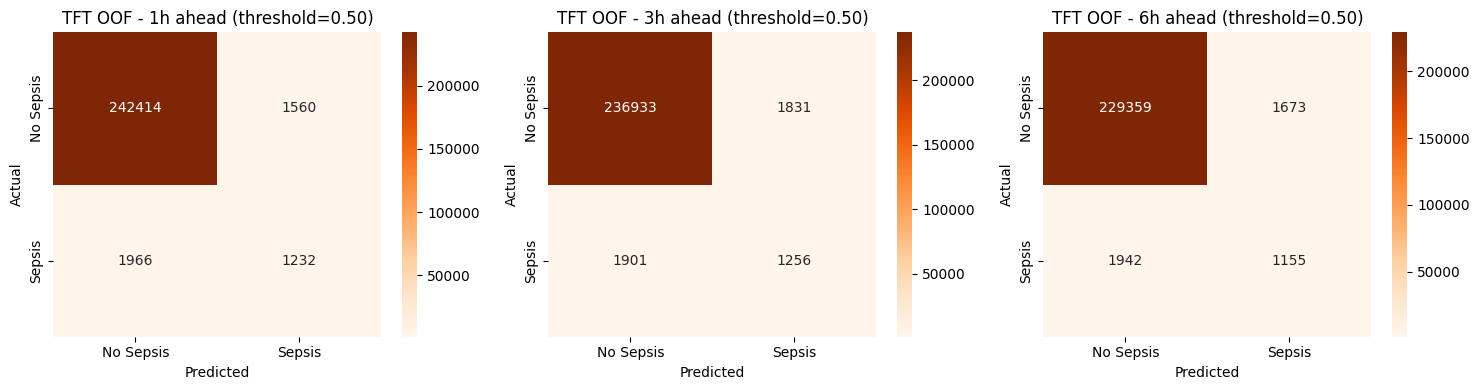

In [17]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 4))

for ax, h in zip(axes, HORIZONS):
    sub = oof_df_tft.dropna(subset=[f"label_{h}h", f"prob_{h}h"]).copy()
    labels = sub[f"label_{h}h"].values.astype(int)
    probs  = sub[f"prob_{h}h"].values
    preds  = (probs >= oof_threshold[h]).astype(int)

    cm = confusion_matrix(labels, preds, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=["No Sepsis", "Sepsis"],
                yticklabels=["No Sepsis", "Sepsis"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"TFT OOF - {h}h ahead (threshold={oof_threshold[h]:.2f})")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "tft_confusion_matrices.png"), dpi=150)
plt.show()

## 18. Save OOF predictions and fold results

In [18]:
oof_df_tft.to_parquet(os.path.join(SAVE_PATH, "oof_tft.parquet"), index=False)
results_df.to_csv(os.path.join(SAVE_PATH, "fold_results_tft.csv"), index=False)
oof_summary_df.to_csv(os.path.join(SAVE_PATH, "oof_summary_tft.csv"), index=False)

best_fold_idx = int(np.argmax(
    [m["AUPRC"] for m in fold_metrics if m["Horizon"] == "1h"]
))

print("Saved:")
print("  oof_tft.parquet")
print("  fold_results_tft.csv")
print("  oof_summary_tft.csv")
print(f"  tft_fold1_best.pt  through  tft_fold{N_FOLDS}_best.pt")
print(f"\nBest fold (by 1h AUPRC): Fold {best_fold_idx+1}")
print("Per-horizon OOF thresholds:")
for h in HORIZONS:
    print(f"  {h}h -> {oof_threshold[h]:.3f}")

Saved:
  oof_tft.parquet
  fold_results_tft.csv
  oof_summary_tft.csv
  tft_fold1_best.pt  through  tft_fold5_best.pt

Best fold (by 1h AUPRC): Fold 4
Per-horizon OOF thresholds:
  1h -> 0.505
  3h -> 0.505
  6h -> 0.505


## Summary

| Metric (1h ahead) | XGBoost (same-hour) | LSTM (same-hour) | TFT (1h ahead) |
|---|---|---|---|
| AUROC | 0.9451 | *see notebook 04* | *see output* |
| AUPRC | 0.5024 | *see notebook 04* | *see output* |
| F1 | 0.5294 | *see notebook 04* | *see output* |
| Recall | 0.4799 | *see notebook 04* | *see output* |

**What the TFT adds over the LSTM**
- Predicts sepsis ahead of time (1h, 3h, 6h) instead of only at the current
  hour, which is what makes the prediction clinically actionable
- The attention layer over the LSTM encoder lets the model look back across
  the whole stay so far when forming each horizon's prediction, rather than
  relying only on the final hidden state
- Static patient covariates (age, gender) are encoded once and added to every
  timestep, separating "who this patient is" from "what is happening to them
  right now"
- Performance is expected to degrade smoothly from 1h to 6h — the per-horizon
  table and confusion matrices above quantify exactly how much warning time
  can be bought before the model's signal becomes too weak to act on
